# 1. Baseband Modulation

This stage models the transmitter's symbol-level packet before waveform shaping. The packet contains front guards, known pilots, QPSK data symbols, and rear guards, so the receiver can later separate timing, channel-training, and payload regions.

The main goal is to verify a clean framing assumption: normalized data symbols, deterministic pilots, zero guard symbols, and the expected packet length of $4+16+128+4=152$ symbols.


In [ ]:
import numpy as np

# 1. Generate 256 random bits
bits = np.random.randint(0, 2, 256)

# 2. Map bits to QPSK symbols (2 bits at a time)
# bit 00 -> Xa = (1, 1j)
# bit 01 -> Xb = (-1, 1j)
# bit 11 -> Xc = (-1, -1j)
# bit 10 -> Xd = (1, -1j)

qpsk_symbols = []
for i in range(0, 256, 2):
    b1, b2 = bits[i], bits[i + 1]
    
    if b1 == 0 and b2 == 0:
        symbol = 1 + 1j  # Xa
    elif b1 == 0 and b2 == 1:
        symbol = -1 + 1j  # Xb
    elif b1 == 1 and b2 == 1:
        symbol = -1 - 1j  # Xc
    else:  # b1 == 1 and b2 == 0
        symbol = 1 - 1j  # Xd
    
    qpsk_symbols.append(symbol)

qpsk_symbols = np.array(qpsk_symbols, dtype=complex)  # Shape: (128,)

# 3. Normalize QPSK symbols (power normalization)
qpsk_symbols_normalized = qpsk_symbols / np.sqrt(2)

# Define rotation matrix for 31.7 degrees (counterclockwise)
# R = [[cos(31.7°), -sin(31.7°)], [sin(31.7°), cos(31.7°)]]
rotation_matrix = np.array([
    [0.851, -0.525],
    [0.525, 0.851]
], dtype=float)

# Apply rotation to each symbol: Xi' = R * Xi
rotated_symbols = []
for symbol in qpsk_symbols_normalized:
    # Convert complex to 2D real column vector [real, imag]^T
    symbol_vector = np.array([[symbol.real], [symbol.imag]], dtype=float)
    
    # Apply rotation matrix
    rotated_vector = rotation_matrix @ symbol_vector
    
    # Convert back to complex
    rotated_symbol = rotated_vector[0, 0] + 1j * rotated_vector[1, 0]
    rotated_symbols.append(rotated_symbol)

rotated_symbols = np.array(rotated_symbols, dtype=complex)

# 4. Construct packet
# Front guard: (0,0) vector × 4
front_guard = np.zeros(4, dtype=complex)

# Pilot: (1,1j)/√2 normalized vector × 16
pilot_symbol = (1 + 1j) / np.sqrt(2)
pilot = np.full(16, pilot_symbol, dtype=complex)

# Data: rotated QPSK symbols × 128
data = rotated_symbols

# Rear guard: (0,0) vector × 4
rear_guard = np.zeros(4, dtype=complex)

# Concatenate to form packet
packet = np.concatenate([front_guard, pilot, data, rear_guard])

# Print results
# print("========== Random Bits ==========")
# print(f"Shape: {bits.shape}")
# print(f"First 16 bits: {bits[:16]}")

# print("\n========== QPSK Symbols (Normalized) ==========")
# print(f"Shape: {qpsk_symbols_normalized.shape}")
# print(f"First 8 symbols:\n{qpsk_symbols_normalized[:8]}")

# print("\n========== Rotated QPSK Symbols ==========")
# print(f"Shape: {rotated_symbols.shape}")
# print(f"First 8 symbols:\n{rotated_symbols[:8]}")

# print("\n========== Packet Structure ==========")
# print(f"Total packet length: {len(packet)} symbols")
# print(f"Front guard (indices 0-3): {packet[:4]}")
# print(f"Pilot (indices 4-19):\n{packet[4:20]}")
# print(f"Data (indices 20-147): First 8 symbols:\n{packet[20:28]}")
# print(f"Rear guard (indices 148-151): {packet[148:]}")

# print(packet)

# 2. Pulse Shaping

This stage models how the symbol packet becomes a sample-rate transmit waveform. Sinc-like pulse shaping (i.e. applying LPF) represent the transmitter filter that limits bandwidth and spreads each symbol over time.

The main goal is to preserve packet timing while producing a realistic complex waveform $$x[n]=\sum_k s[k]g[n-kL]$$ with well-defined pulse energy for later matched filtering.


In [13]:
# 2. Pulse Shaping

# Set symbol spacing factor
L = 8

# Define discrete time range n from -8 to 1216 inclusive
n = np.arange(0, 1217)

# Define sinc pulse g(t) = sin(pi t) / (pi t)
def g(t):
    return np.sinc(t)

# Build transmit waveform x[n] = sum_k packet[k] * g[n - kL]
k = np.arange(packet.size)

# Use broadcasting for efficient computation
pulse_matrix = g(n[np.newaxis, :] - k[:, np.newaxis] * L)
x = np.sum(packet[:, np.newaxis] * pulse_matrix, axis=0)

# Optional diagnostics
# print(f"L = {L}")
# print(f"n range = [{n[0]}, {n[-1]}], length = {n.size}")
# print(f"packet length = {packet.size}")
# print(f"waveform length = {x.size}")
# print(f"first 8 waveform samples:\n{x[:8]}")

# print(f"first 8 waveform samples:\n{x[899:907]}")

# 3. Wireless Channel

This stage models propagation through a flat block-fading wireless channel with additive complex Gaussian noise. One complex channel coefficient applies to the whole packet, representing constant amplitude and phase distortion during that packet.

The received waveform follows $$y[n]=h x[n]+w[n]$$ 


In [14]:
# 3. Wireless Channel

In [17]:
# 3. Wireless Channel

# 1. Generate channel coefficient h ~ CN(0,1)
# h = (X + jY)/sqrt(2), where X, Y ~ N(0,1)
# This channel remains constant for the entire packet (one value for all 1225 samples)
X = np.random.normal(0, 1)
Y = np.random.normal(0, 1)
h = (X + 1j * Y) / np.sqrt(2)

# 2. Generate noise array w[n] ~ CN(0,1) for each sample n
# w has the same length as x (1225 samples)
# Each element w[n] is a new independent CN(0,1) sample
w_real = np.random.normal(0, 1, size=x.size)
w_imag = np.random.normal(0, 1, size=x.size)
w = (w_real + 1j * w_imag) / np.sqrt(18)

# 3. Received signal y[n] = h*x[n] + w[n]
# h is multiplied with each element of x, then w[n] is added element-wise
y = h * x + w

print(f"Channel coefficient h = {h}")
print(f"Channel magnitude |h| = {np.abs(h)}")
print(f"Noise length w.size = {w.size}")
print(f"Received signal length y.size = {y.size}")
print(f"\nFirst 10 noise samples:\n{w[:10]}")
print(f"\nFirst 10 received samples:\n{y[:10]}")

Channel coefficient h = (0.2536131411364355+1.2369456880011773j)
Channel magnitude |h| = 1.262677417403905
Noise length w.size = 1217
Received signal length y.size = 1217

First 10 noise samples:
[-0.46133962+0.45899803j -0.01683138-0.03924025j -0.07769056+0.04392829j
  0.30086652-0.19319144j -0.24085729-0.16519608j  0.06523035+0.01628205j
 -0.03666497-0.39538068j  0.00229886+0.23079038j  0.10403712+0.07408022j
  0.05123467-0.14961205j]

First 10 received samples:
[-0.46133962+0.45899803j -0.01683138-0.03924025j -0.07769056+0.04392829j
  0.30086652-0.19319144j -0.24085729-0.16519608j  0.06523035+0.01628205j
 -0.03666497-0.39538068j  0.00229886+0.23079038j  0.10403712+0.07408022j
  0.05123467-0.14961205j]


# 4. Channel Estimation

This stage models how the receiver estimates the unknown channel using the known pilot symbols. After receive filtering and symbol-rate sampling, the pilot region is treated as $$\mathbf{y}_p=h\mathbf{x}_p+\mathbf{w}_p$$

The main goal is to obtain a reliable scalar channel estimate, such as LS or MMSE, that is accurate enough to equalize the data symbols in the same packet.


In [18]:
# 4. Channel Estimation

In [16]:

# Sample the received waveform at symbol rate using the same symbol spacing L.
# We take y[0], y[8], y[16], ..., y[151*8] to form 152 symbol-rate samples.
symbol_indices = np.arange(packet.size) * L
y_samples = y[symbol_indices]

# Skip the first 4 guard symbols and select the 16 pilot symbols for channel estimation.
guard_length = 4
pilot_length = 16
y_pilot = y_samples[guard_length:guard_length + pilot_length]

# Known pilot symbols are all (1 + 1j)/sqrt(2).
xp = np.full(pilot_length, (1 + 1j) / np.sqrt(2), dtype=complex)

# LS channel estimate: h_hat = sum(conj(xp[k]) * y_pilot[k]) / sum(|xp[k]|^2)
numerator = np.sum(np.conj(xp) * y_pilot)
denominator = np.sum(np.abs(xp) ** 2)
h_est = numerator / denominator

print(f"Symbol-rate samples length = {y_samples.size}")
print(f"Pilot samples length = {y_pilot.size}")
print(f"Estimated channel h_est = {h_est}")

Symbol-rate samples length = 152
Pilot samples length = 16
Estimated channel h_est = (0.0892447008383811+0.06479579026455065j)


# 5. Baseband Demodulation

This stage models coherent receiver detection after channel equalization. Only the data region is detected; pilots and guards are excluded from payload recovery.

The main goal is to map equalized symbols back to QPSK decisions, recover bits, and evaluate SER, BER, PER, and the BER-versus-SNR trend of the full end-to-end communication.


In [ ]:
# 1. Equalize the received signal using estimated channel
# x_eq[k] = y_samples[k] / h_est
x_eq = y_samples / h_est

# 2. Extract 128 data symbols (skip first 4 guards at indices 0-3 and last 4 guards at indices 148-151)
# Data symbols are at indices 20-147 in the original packet structure (4 guards + 16 pilots + 128 data)
# But in y_samples we already have symbol-rate sampled, so indices 4:132 give us 128 data symbols
x_data = x_eq[4:132]

# 3. Define inverse rotation matrix R^(-1)
# R^(-1) = [[0.851, 0.525], [-0.525, 0.851]]
R_inv = np.array([
    [0.851, 0.525],
    [-0.525, 0.851]
], dtype=float)

# 4. Apply inverse rotation to get S_a (decoded symbols)
S_a = []
for symbol in x_data:
    # Convert complex to 2D real column vector [real, imag]^T
    symbol_vector = np.array([[symbol.real], [symbol.imag]], dtype=float)
    
    # Apply inverse rotation matrix: S_a = R_inv @ symbol_vector
    decoded_vector = R_inv @ symbol_vector
    
    # Convert back to complex
    decoded_symbol = decoded_vector[0, 0] + 1j * decoded_vector[1, 0]
    S_a.append(decoded_symbol)

S_a = np.array(S_a, dtype=complex)

# 5. Map symbols to bits based on sign of real and imaginary parts
# real > 0, imag > 0: 00
# real < 0, imag > 0: 01
# real < 0, imag < 0: 11
# real > 0, imag < 0: 10

bit_a = []
for symbol in S_a:
    real_sign = 0 if symbol.real > 0 else 1
    imag_sign = 0 if symbol.imag > 0 else 1
    
    if real_sign == 0 and imag_sign == 0:
        bit_a.extend([0, 0])
    elif real_sign == 1 and imag_sign == 0:
        bit_a.extend([0, 1])
    elif real_sign == 1 and imag_sign == 1:
        bit_a.extend([1, 1])
    else:  # real_sign == 0 and imag_sign == 1
        bit_a.extend([1, 0])

bit_a = np.array(bit_a)

# 6. Compare decoded bits with original bits and calculate BER
bit_error = np.sum(bit_a != bits)
BER = bit_error / 256

print(f"BER = {BER}")

# 7. Group bits into symbols (2 bits per symbol) and create symbol lists
symbols_original = []
symbols_decoded = []

for k in range(0, 256, 2):
    # Original symbols (from original bits)
    b1_orig, b2_orig = bits[k], bits[k+1]
    
    if b1_orig == 0 and b2_orig == 0:
        sym_orig = 1 + 1j
    elif b1_orig == 0 and b2_orig == 1:
        sym_orig = -1 + 1j
    elif b1_orig == 1 and b2_orig == 1:
        sym_orig = -1 - 1j
    else:  # b1_orig == 1 and b2_orig == 0
        sym_orig = 1 - 1j
    
    symbols_original.append(sym_orig)
    
    # Decoded symbols (from decoded bits bit_a)
    b1_dec, b2_dec = bit_a[k], bit_a[k+1]
    
    if b1_dec == 0 and b2_dec == 0:
        sym_dec = 1 + 1j
    elif b1_dec == 0 and b2_dec == 1:
        sym_dec = -1 + 1j
    elif b1_dec == 1 and b2_dec == 1:
        sym_dec = -1 - 1j
    else:  # b1_dec == 1 and b2_dec == 0
        sym_dec = 1 - 1j
    
    symbols_decoded.append(sym_dec)

symbols_original = np.array(symbols_original, dtype=complex)
symbols_decoded = np.array(symbols_decoded, dtype=complex)

# 8. Compare symbols and calculate SER
symbol_error = np.sum(symbols_original != symbols_decoded)
SER = symbol_error / 128

print(f"SER = {SER}")

BER = 0.50390625
SER = 0.78125


# 8. Monte Carlo Simulation with SNR Variation (100 Iterations × 5 SNR Levels)

This stage sweeps through different Signal-to-Noise Ratio (SNR) values (1, 2, 3, 4, 5) while running the full communication pipeline 100 times at each SNR level. This allows us to observe how BER, SER, and PER degrade with decreasing SNR, revealing the performance-versus-noise tradeoff.

The noise is defined as $w[n] = \frac{w_{real}[n] + j \cdot w_{imag}[n]}{\sqrt{2 \cdot \text{SNR}^2}}$ where the denominator scales inversely with SNR to control noise power.



In [47]:
# 8. Monte Carlo Simulation with SNR Variation - 5 SNR levels × 100 iterations each

import numpy as np

# Define SNR levels to sweep
SNR_levels = [1, 2, 3, 4, 5]

# Storage for results at each SNR level
results_per_snr = {}

print("========== Starting SNR Sweep Simulation ==========\n")

# Loop over each SNR level
for SNR in SNR_levels:
    print(f"Running simulation for SNR = {SNR}...")
    
    # Lists to store BER, SER, PER for this SNR level
    BER_list_snr = []
    SER_list_snr = []
    PER_count_snr = 0
    
    # Run 100 iterations for this SNR
    for iteration in range(100):
        # ========== 1. Baseband Modulation ==========
        bits_iter = np.random.randint(0, 2, 256)
        
        qpsk_symbols_iter = []
        for i in range(0, 256, 2):
            b1, b2 = bits_iter[i], bits_iter[i + 1]
            
            if b1 == 0 and b2 == 0:
                symbol = 1 + 1j
            elif b1 == 0 and b2 == 1:
                symbol = -1 + 1j
            elif b1 == 1 and b2 == 1:
                symbol = -1 - 1j
            else:
                symbol = 1 - 1j
            
            qpsk_symbols_iter.append(symbol)
        
        qpsk_symbols_iter = np.array(qpsk_symbols_iter, dtype=complex)
        qpsk_symbols_normalized_iter = qpsk_symbols_iter / np.sqrt(2)
        
        rotation_matrix_iter = np.array([
            [0.851, -0.525],
            [0.525, 0.851]
        ], dtype=float)
        
        rotated_symbols_iter = []
        for symbol in qpsk_symbols_normalized_iter:
            symbol_vector = np.array([[symbol.real], [symbol.imag]], dtype=float)
            rotated_vector = rotation_matrix_iter @ symbol_vector
            rotated_symbol = rotated_vector[0, 0] + 1j * rotated_vector[1, 0]
            rotated_symbols_iter.append(rotated_symbol)
        
        rotated_symbols_iter = np.array(rotated_symbols_iter, dtype=complex)
        
        # Construct packet
        front_guard_iter = np.zeros(4, dtype=complex)
        pilot_symbol_iter = (1 + 1j) / np.sqrt(2)
        pilot_iter = np.full(16, pilot_symbol_iter, dtype=complex)
        data_iter = rotated_symbols_iter
        rear_guard_iter = np.zeros(4, dtype=complex)
        
        packet_iter = np.concatenate([front_guard_iter, pilot_iter, data_iter, rear_guard_iter])
        
        # ========== 2. Pulse Shaping ==========
        L_iter = 8
        n_iter = np.arange(0, 1217)
        
        def g_iter(t):
            return np.sinc(t)
        
        k_iter = np.arange(packet_iter.size)
        pulse_matrix_iter = g_iter(n_iter[np.newaxis, :] - k_iter[:, np.newaxis] * L_iter)
        x_iter = np.sum(packet_iter[:, np.newaxis] * pulse_matrix_iter, axis=0)
        
        # ========== 3. Wireless Channel ==========
        X_iter = np.random.normal(0, 1)
        Y_iter = np.random.normal(0, 1)
        h_iter = (X_iter + 1j * Y_iter) / np.sqrt(2)
        
        # Generate noise with SNR-dependent scaling
        w_real_iter = np.random.normal(0, 1, size=x_iter.size)
        w_imag_iter = np.random.normal(0, 1, size=x_iter.size)
        w_iter = (w_real_iter + 1j * w_imag_iter) / np.sqrt(2 * SNR**2)
        
        # Received signal
        y_iter = h_iter * x_iter + w_iter
        
        # ========== 4. Channel Estimation ==========
        symbol_indices_iter = np.arange(packet_iter.size) * L_iter
        y_samples_iter = y_iter[symbol_indices_iter]
        
        guard_length_iter = 4
        pilot_length_iter = 16
        y_pilot_iter = y_samples_iter[guard_length_iter:guard_length_iter + pilot_length_iter]
        
        xp_iter = np.full(pilot_length_iter, (1 + 1j) / np.sqrt(2), dtype=complex)
        
        numerator_iter = np.sum(np.conj(xp_iter) * y_pilot_iter)
        denominator_iter = np.sum(np.abs(xp_iter) ** 2)
        h_est_iter = numerator_iter / denominator_iter
        
        # ========== 5. Baseband Demodulation ==========
        x_eq_iter = y_samples_iter / h_est_iter
        x_data_iter = x_eq_iter[20:148]
        
        R_inv_iter = np.array([
            [0.851, 0.525],
            [-0.525, 0.851]
        ], dtype=float)
        
        S_a_iter = []
        for symbol in x_data_iter:
            symbol_vector = np.array([[symbol.real], [symbol.imag]], dtype=float)
            decoded_vector = R_inv_iter @ symbol_vector
            decoded_symbol = decoded_vector[0, 0] + 1j * decoded_vector[1, 0]
            S_a_iter.append(decoded_symbol)
        
        S_a_iter = np.array(S_a_iter, dtype=complex)
        
        bit_a_iter = []
        for symbol in S_a_iter:
            real_sign = 0 if symbol.real > 0 else 1
            imag_sign = 0 if symbol.imag > 0 else 1
            
            if real_sign == 0 and imag_sign == 0:
                bit_a_iter.extend([0, 0])
            elif real_sign == 1 and imag_sign == 0:
                bit_a_iter.extend([0, 1])
            elif real_sign == 1 and imag_sign == 1:
                bit_a_iter.extend([1, 1])
            else:
                bit_a_iter.extend([1, 0])
        
        bit_a_iter = np.array(bit_a_iter)
        
        # Calculate BER
        bit_error_iter = np.sum(bit_a_iter != bits_iter)
        BER_iter = bit_error_iter / 256
        BER_list_snr.append(BER_iter)
        
        # Calculate PER
        if bit_error_iter > 0:
            PER_count_snr += 1
        
        # Calculate SER
        symbols_original_iter = []
        symbols_decoded_iter = []
        
        for k in range(0, 256, 2):
            b1_orig, b2_orig = bits_iter[k], bits_iter[k+1]
            
            if b1_orig == 0 and b2_orig == 0:
                sym_orig = 1 + 1j
            elif b1_orig == 0 and b2_orig == 1:
                sym_orig = -1 + 1j
            elif b1_orig == 1 and b2_orig == 1:
                sym_orig = -1 - 1j
            else:
                sym_orig = 1 - 1j
            
            symbols_original_iter.append(sym_orig)
            
            b1_dec, b2_dec = bit_a_iter[k], bit_a_iter[k+1]
            
            if b1_dec == 0 and b2_dec == 0:
                sym_dec = 1 + 1j
            elif b1_dec == 0 and b2_dec == 1:
                sym_dec = -1 + 1j
            elif b1_dec == 1 and b2_dec == 1:
                sym_dec = -1 - 1j
            else:
                sym_dec = 1 - 1j
            
            symbols_decoded_iter.append(sym_dec)
        
        symbols_original_iter = np.array(symbols_original_iter, dtype=complex)
        symbols_decoded_iter = np.array(symbols_decoded_iter, dtype=complex)
        
        symbol_error_iter = np.sum(symbols_original_iter != symbols_decoded_iter)
        SER_iter = symbol_error_iter / 128
        SER_list_snr.append(SER_iter)
        
        if (iteration + 1) % 20 == 0:
            print(f"  SNR={SNR}, Iteration {iteration + 1}: BER = {BER_iter:.4f}, SER = {SER_iter:.4f}")
    
    # Store results for this SNR level
    results_per_snr[SNR] = {
        'BER_list': BER_list_snr,
        'SER_list': SER_list_snr,
        'PER': PER_count_snr / 100,
        'avg_BER': np.mean(BER_list_snr),
        'avg_SER': np.mean(SER_list_snr),
        'std_BER': np.std(BER_list_snr),
        'std_SER': np.std(SER_list_snr)
    }
    
    print(f"  SNR={SNR}: Avg BER={results_per_snr[SNR]['avg_BER']:.6f}, Avg SER={results_per_snr[SNR]['avg_SER']:.6f}, PER={results_per_snr[SNR]['PER']:.4f}\n")

print("========== SNR Sweep Simulation Complete ==========\n")

# Print summary
print("========== Summary of Results Across SNR Levels ==========")
for SNR in SNR_levels:
    print(f"SNR = {SNR}:")
    print(f"  BER: avg={results_per_snr[SNR]['avg_BER']:.6f}, std={results_per_snr[SNR]['std_BER']:.6f}")
    print(f"  SER: avg={results_per_snr[SNR]['avg_SER']:.6f}, std={results_per_snr[SNR]['std_SER']:.6f}")
    print(f"  PER: {results_per_snr[SNR]['PER']:.4f}")
    print()



========== Starting SNR Sweep Simulation ==========

Running simulation for SNR = 1...
  SNR=1, Iteration 20: BER = 0.0742, SER = 0.1484
  SNR=1, Iteration 40: BER = 0.0508, SER = 0.0938
  SNR=1, Iteration 60: BER = 0.1055, SER = 0.2031
  SNR=1, Iteration 80: BER = 0.2383, SER = 0.3750
  SNR=1, Iteration 100: BER = 0.3086, SER = 0.5078
  SNR=1: Avg BER=0.212656, Avg SER=0.369375, PER=0.9900

Running simulation for SNR = 2...
  SNR=2, Iteration 20: BER = 0.3125, SER = 0.5625
  SNR=2, Iteration 40: BER = 0.0469, SER = 0.0938
  SNR=2, Iteration 60: BER = 0.0039, SER = 0.0078
  SNR=2, Iteration 80: BER = 0.0664, SER = 0.1172
  SNR=2, Iteration 100: BER = 0.2227, SER = 0.4062
  SNR=2: Avg BER=0.093320, Avg SER=0.167344, PER=0.9000

Running simulation for SNR = 3...
  SNR=3, Iteration 20: BER = 0.0078, SER = 0.0156
  SNR=3, Iteration 40: BER = 0.0469, SER = 0.0938
  SNR=3, Iteration 60: BER = 0.0000, SER = 0.0000
  SNR=3, Iteration 80: BER = 0.0000, SER = 0.0000
  SNR=3, Iteration 100: BER =

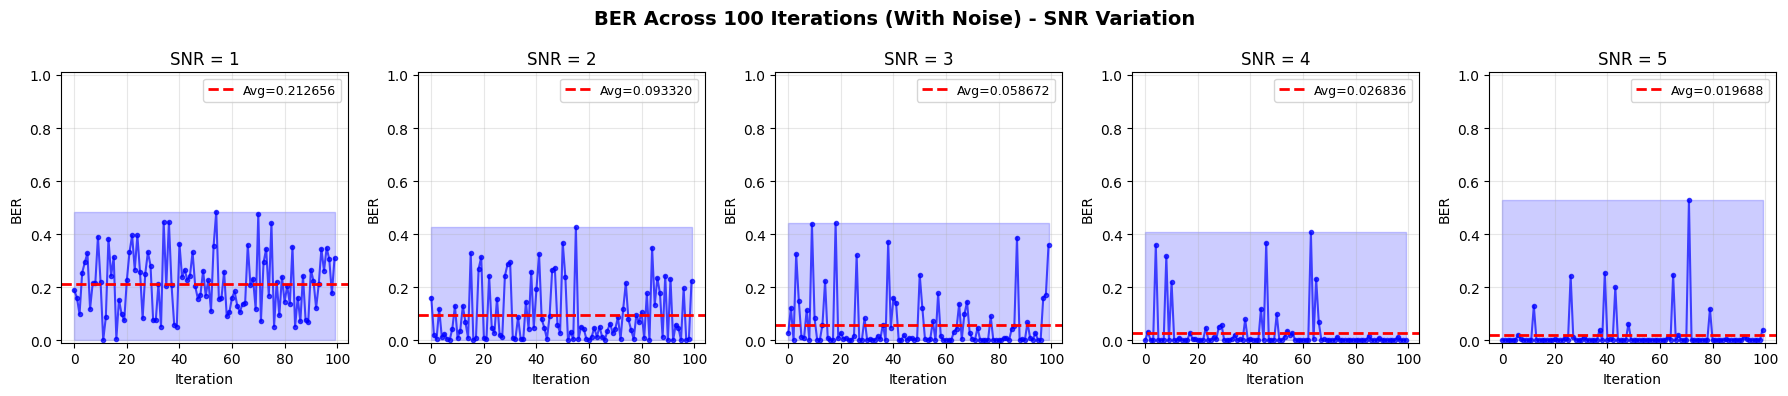

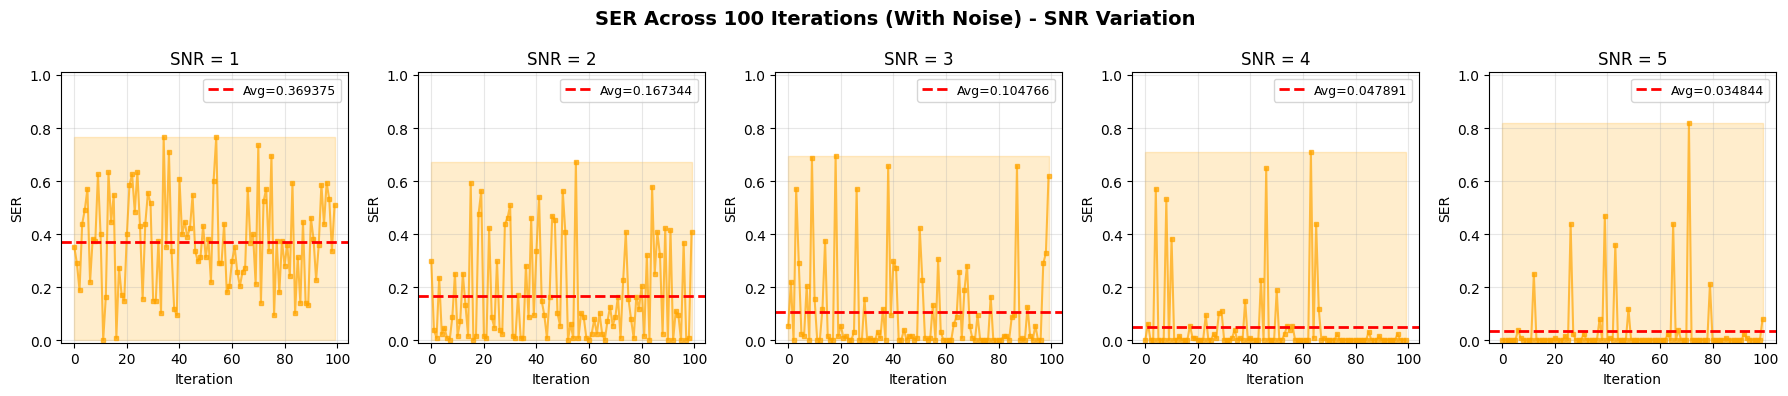

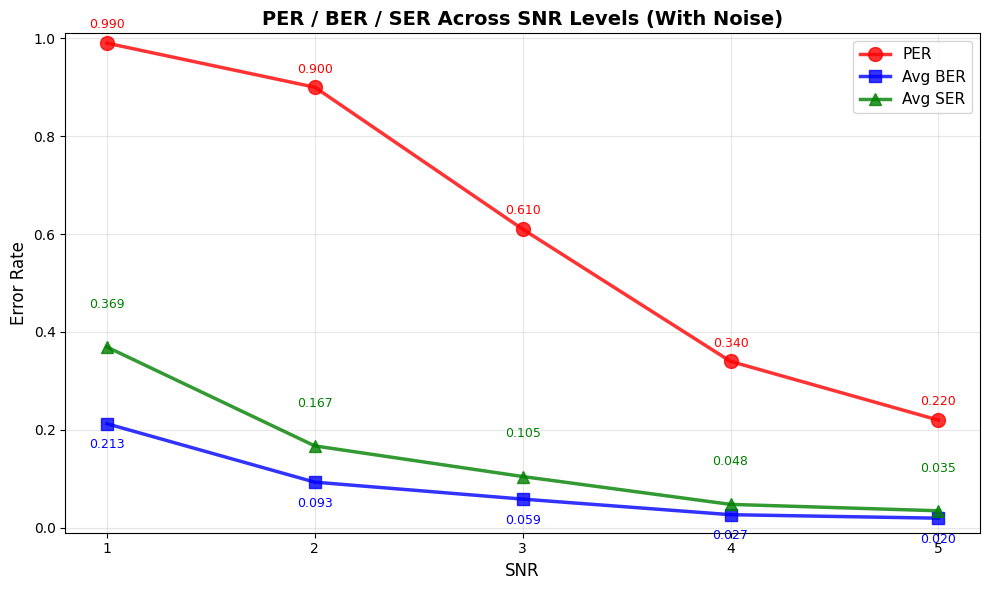


========== Detailed SNR Sweep Analysis ==========

SNR = 1:
  BER: Mean=0.212656, Std=0.112130
       Min=0.000000, Max=0.484375
  SER: Mean=0.369375, Std=0.176563
       Min=0.000000, Max=0.765625
  PER: 0.9900 (99/100 packets with errors)

SNR = 2:
  BER: Mean=0.093320, Std=0.107635
       Min=0.000000, Max=0.425781
  SER: Mean=0.167344, Std=0.183666
       Min=0.000000, Max=0.671875
  PER: 0.9000 (90/100 packets with errors)

SNR = 3:
  BER: Mean=0.058672, Std=0.103722
       Min=0.000000, Max=0.441406
  SER: Mean=0.104766, Std=0.176715
       Min=0.000000, Max=0.695312
  PER: 0.6100 (61/100 packets with errors)

SNR = 4:
  BER: Mean=0.026836, Std=0.077819
       Min=0.000000, Max=0.406250
  SER: Mean=0.047891, Std=0.134736
       Min=0.000000, Max=0.710938
  PER: 0.3400 (34/100 packets with errors)

SNR = 5:
  BER: Mean=0.019688, Std=0.070814
       Min=0.000000, Max=0.527344
  SER: Mean=0.034844, Std=0.119245
       Min=0.000000, Max=0.820312
  PER: 0.2200 (22/100 packets with er

In [48]:
# === Visualization: Section 8 - SNR Sweep Results ===

import matplotlib.pyplot as plt
import numpy as np

# Plot 1: BER Across 100 Iterations for Each SNR Level
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('BER Across 100 Iterations (With Noise) - SNR Variation', fontsize=14, fontweight='bold')

for idx, SNR in enumerate(SNR_levels):
    ax = axes[idx]
    BER_data = results_per_snr[SNR]['BER_list']
    avg_BER = results_per_snr[SNR]['avg_BER']
    
    ax.plot(BER_data, linewidth=1.5, marker='o', markersize=3, alpha=0.7, color='blue')
    ax.axhline(y=avg_BER, color='red', linestyle='--', linewidth=2, label=f'Avg={avg_BER:.6f}')
    ax.fill_between(range(len(BER_data)), np.min(BER_data), np.max(BER_data), alpha=0.2, color='blue')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('BER')
    ax.set_title(f'SNR = {SNR}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

# Plot 2: SER Across 100 Iterations for Each SNR Level
fig, axes = plt.subplots(1, 5, figsize=(18, 4))
fig.suptitle('SER Across 100 Iterations (With Noise) - SNR Variation', fontsize=14, fontweight='bold')

for idx, SNR in enumerate(SNR_levels):
    ax = axes[idx]
    SER_data = results_per_snr[SNR]['SER_list']
    avg_SER = results_per_snr[SNR]['avg_SER']
    
    ax.plot(SER_data, linewidth=1.5, marker='s', markersize=3, alpha=0.7, color='orange')
    ax.axhline(y=avg_SER, color='red', linestyle='--', linewidth=2, label=f'Avg={avg_SER:.6f}')
    ax.fill_between(range(len(SER_data)), np.min(SER_data), np.max(SER_data), alpha=0.2, color='orange')
    
    ax.set_xlabel('Iteration')
    ax.set_ylabel('SER')
    ax.set_title(f'SNR = {SNR}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_ylim(-0.01, 1.01)

plt.tight_layout()
plt.show()

# Plot 3: PER Across SNR (Single plot showing trend)
fig, ax = plt.subplots(figsize=(10, 6))

PER_values = [results_per_snr[SNR]['PER'] for SNR in SNR_levels]
BER_values = [results_per_snr[SNR]['avg_BER'] for SNR in SNR_levels]
SER_values = [results_per_snr[SNR]['avg_SER'] for SNR in SNR_levels]

ax.plot(SNR_levels, PER_values, linewidth=2.5, marker='o', markersize=10, label='PER', color='red', alpha=0.8)
ax.plot(SNR_levels, BER_values, linewidth=2.5, marker='s', markersize=8, label='Avg BER', color='blue', alpha=0.8)
ax.plot(SNR_levels, SER_values, linewidth=2.5, marker='^', markersize=8, label='Avg SER', color='green', alpha=0.8)

ax.set_xlabel('SNR', fontsize=12)
ax.set_ylabel('Error Rate', fontsize=12)
ax.set_title('PER / BER / SER Across SNR Levels (With Noise)', fontsize=14, fontweight='bold')
ax.set_xticks(SNR_levels)
ax.grid(True, alpha=0.3)
ax.legend(fontsize=11)
ax.set_ylim(-0.01, 1.01)

# Add value labels on points
for idx, SNR in enumerate(SNR_levels):
    ax.text(SNR, PER_values[idx] + 0.03, f'{PER_values[idx]:.3f}', ha='center', fontsize=9, color='red')
    ax.text(SNR, BER_values[idx] - 0.05, f'{BER_values[idx]:.3f}', ha='center', fontsize=9, color='blue')
    ax.text(SNR, SER_values[idx] + 0.08, f'{SER_values[idx]:.3f}', ha='center', fontsize=9, color='green')

plt.tight_layout()
plt.show()

# Print detailed SNR sweep summary
print("\n========== Detailed SNR Sweep Analysis ==========\n")
for SNR in SNR_levels:
    print(f"SNR = {SNR}:")
    print(f"  BER: Mean={results_per_snr[SNR]['avg_BER']:.6f}, Std={results_per_snr[SNR]['std_BER']:.6f}")
    print(f"       Min={np.min(results_per_snr[SNR]['BER_list']):.6f}, Max={np.max(results_per_snr[SNR]['BER_list']):.6f}")
    print(f"  SER: Mean={results_per_snr[SNR]['avg_SER']:.6f}, Std={results_per_snr[SNR]['std_SER']:.6f}")
    print(f"       Min={np.min(results_per_snr[SNR]['SER_list']):.6f}, Max={np.max(results_per_snr[SNR]['SER_list']):.6f}")
    print(f"  PER: {results_per_snr[SNR]['PER']:.4f} ({int(results_per_snr[SNR]['PER']*100)}/100 packets with errors)")
    print()

